In [1]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import h5py
import numpy as np
import random

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [3]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [36]:
def pars(i, mstar):

    arr = np.vstack( (mstar, np.ones(len(mstar)) * wind_en[i],\
                        np.ones(len(mstar)) * wind_vel[i],\
                        np.ones(len(mstar)) * radio_fb[i],\
                        np.ones(len(mstar)) * radio_fb_reo[i],\
                        np.ones(len(mstar)) * omega_matter[i],\
                        np.ones(len(mstar)) * sigma_8[i] )).T

    return arr

### Get the data

In [37]:
smf = {}
for i in range(26):
    smf[i] = utils.camels_stellar_mf('CV', num=i, nbins=15)

train_sel = range(26)

In [38]:
#del smf_global, arr_global
mstar = np.log10(smf[train_sel[0]]['mstar'][:-3])
arr_global = pars(0, mstar)
smf_global = np.log10(smf[train_sel[0]]['smf'][:-3])

for i in range(1,26):
    mstar = np.log10(smf[train_sel[i]]['mstar'][:-3])

    arr = pars(train_sel[i], mstar)

    arr_global = np.vstack((arr_global, arr))

    smf_global = np.hstack((smf_global, np.log10(smf[train_sel[i]]['smf'][:-3])))

isnan = np.where(np.isnan(arr_global))[0]

arr_global = np.delete(arr_global, isnan, axis=0)
smf_global = np.delete(smf_global, isnan)

NameError: name 'wind_en' is not defined

In [ ]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=7))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

In [25]:
mean_smf = np.zeros(len(smf[0]['smf']))
mean_mstar = np.zeros(len(smf[0]['mstar']))
for i in range(26):
    mean_smf += smf[i]['smf'] / 26
    mean_mstar += smf[i]['mstar'] / 26

var_smf = np.zeros(len(smf[0]['smf']))
for i in range(26):
    var_smf += ( smf[i]['smf'] - mean_smf )**2 / 26

stddev_smf = np.sqrt(var_smf)

In [47]:
0.5*(np.log10(1+stddev_smf[:-5]/smf[i]['smf'][:-5]) - np.log10(1-stddev_smf[:-5]/smf[i]['smf'][:-5]))

array([0.02509286, 0.04012347, 0.03010014, 0.03498795, 0.03805   ,
       0.04930883, 0.05057655, 0.09816664, 0.08654314])

Text(0.5, 1.0, 'Cosmic-Variance Set')

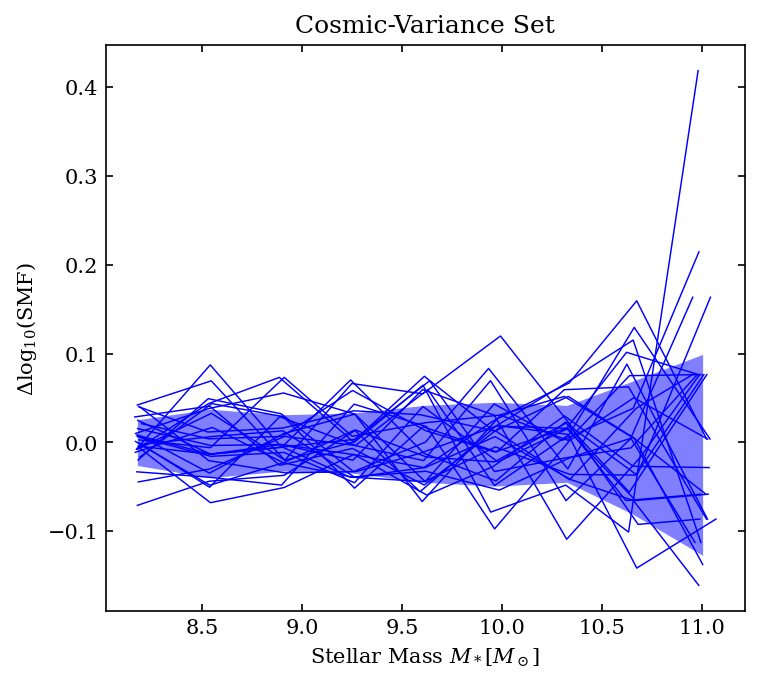

In [32]:
# Initialize plot
f, ax = plt.subplots(1, figsize=(5.5, 5), dpi=150)

for i in range(26):    
    ax.plot(np.log10(smf[i]['mstar'][:-5]),  np.log10(mean_smf[:-5]) - np.log10(smf[i]['smf'][:-5]), color='b', lw=0.7)

ax.fill_between(np.log10(mean_mstar[:-5]), np.log10(1-stddev_smf[:-5]/mean_smf[:-5]), np.log10(1+stddev_smf[:-5]/mean_smf[:-5]), color='b', alpha=0.5, edgecolor=None)

ax.set_ylabel('$\Delta \log_{10}(\\mathrm{SMF})$')
ax.set_xlabel('Stellar Mass $M_*[M_\odot]$')
ax.set_title('Cosmic-Variance Set')

In [19]:
np.sqrt(var_smf)

array([1.86409015e-03, 1.96047035e-03, 1.32620252e-03, 1.25263275e-03,
       1.28040941e-03, 1.02477835e-03, 8.16572797e-04, 8.63713393e-04,
       4.17635492e-04, 1.93409537e-04, 1.15640480e-04, 6.71597916e-05,
       2.39849683e-05, 4.44089210e-16])

In [388]:
#del smf_global, arr_global
mstar = np.log10(smf[train_sel[0]]['mstar'][:-3])
arr_global = pars(0, mstar)
smf_global = np.log10(smf[train_sel[0]]['smf'][:-3])

for i in range(1,40):
    mstar = np.log10(smf[train_sel[i]]['mstar'][:-3])

    arr = pars(train_sel[i], mstar)

    arr_global = np.vstack((arr_global, arr))

    smf_global = np.hstack((smf_global, np.log10(smf[train_sel[i]]['smf'][:-3])))

isnan = np.where(np.isnan(arr_global))[0]

arr_global = np.delete(arr_global, isnan, axis=0)
smf_global = np.delete(smf_global, isnan)

/tmp/ipykernel_431096/3858746572.py:13: RuntimeWarning: divide by zero encountered in log10
  smf_global = np.hstack((smf_global, np.log10(smf[train_sel[i]]['smf'][:-3])))


In [389]:
#Training data is 100 points in [0,1] inclusive regularly spaced
#train_x = torch.vstack([torch.linspace(0, 1, 100),torch.linspace(0, 1, 100)]).T
#True function is sin(2*pi*x) with Gaussian noise
#train_y = torch.sin(train_x[:,0] * (2 * math.pi)) + torch.randn(train_x[:,0].size()) * math.sqrt(0.04)

In [390]:
train_x = torch.asarray(arr_global, dtype=torch.float)
train_y = torch.asarray(smf_global, dtype=torch.float)

### Build the GP Model

In [391]:
# We will use the simplest form of GP model, exact inference
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=7))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

In [420]:
# # We will use the simplest form of GP model, exact inference
# class SpectralMixtureGPModel(gpytorch.models.ExactGP):
#     def __init__(self, train_x, train_y, likelihood):
#         super(SpectralMixtureGPModel, self).__init__(train_x, train_y, likelihood)
#         self.mean_module = gpytorch.means.ConstantMean()
#         self.covar_module = gpytorch.kernels.SpectralMixtureKernel(num_mixtures=4)
#         #self.covar_module.initialize_from_data(train_x, train_y)

#     def forward(self, x):
#         mean_x = self.mean_module(x)
#         covar_x = self.covar_module(x)
#         return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# # initialize likelihood and model
# likelihood = gpytorch.likelihoods.GaussianLikelihood()
# model = SpectralMixtureGPModel(train_x, train_y, likelihood)

#### Train it

In [393]:
# this is for running the notebook in our testing framework
import os
smoke_test = ('CI' in os.environ)
training_iter = 2 if smoke_test else 200


# Find optimal model hyperparameters
model.train()
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -torch.sum(mll(output, train_y))
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

Iter 1/200 - Loss: 1.413   noise: 0.693
Iter 2/200 - Loss: 1.277   noise: 0.644
Iter 3/200 - Loss: 1.166   noise: 0.598
Iter 4/200 - Loss: 1.072   noise: 0.554
Iter 5/200 - Loss: 0.993   noise: 0.513
Iter 6/200 - Loss: 0.923   noise: 0.473
Iter 7/200 - Loss: 0.860   noise: 0.436
Iter 8/200 - Loss: 0.801   noise: 0.402
Iter 9/200 - Loss: 0.746   noise: 0.369
Iter 10/200 - Loss: 0.694   noise: 0.339
Iter 11/200 - Loss: 0.643   noise: 0.310
Iter 12/200 - Loss: 0.594   noise: 0.284
Iter 13/200 - Loss: 0.546   noise: 0.259
Iter 14/200 - Loss: 0.499   noise: 0.237
Iter 15/200 - Loss: 0.452   noise: 0.216
Iter 16/200 - Loss: 0.406   noise: 0.196
Iter 17/200 - Loss: 0.361   noise: 0.179
Iter 18/200 - Loss: 0.317   noise: 0.162
Iter 19/200 - Loss: 0.274   noise: 0.147
Iter 20/200 - Loss: 0.231   noise: 0.134
Iter 21/200 - Loss: 0.190   noise: 0.121
Iter 22/200 - Loss: 0.149   noise: 0.110
Iter 23/200 - Loss: 0.110   noise: 0.100
Iter 24/200 - Loss: 0.072   noise: 0.090
Iter 25/200 - Loss: 0.035

In [445]:
mstar_test = np.linspace(8,11,15)
test_x1 = torch.asarray(pars(train_sel[5], np.log10(smf[train_sel[5]]['mstar'][:-5])), dtype=torch.float)
test_x2 = torch.asarray(pars(test_sel[10], np.log10(smf[test_sel[10]]['mstar'][:-5])), dtype=torch.float)

In [446]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred1 = likelihood(model(test_x1))
    observed_pred2 = likelihood(model(test_x2))

Text(0, 0.5, 'SMF')

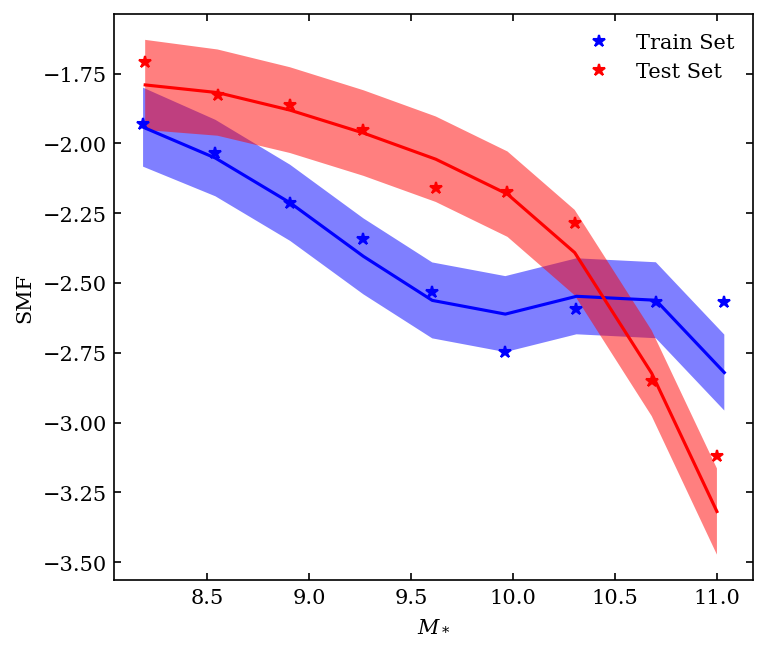

In [448]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(5.5, 5), dpi=150)

    # Get upper and lower confidence bounds
    lower1, upper1 = observed_pred1.confidence_region()
    lower2, upper2 = observed_pred2.confidence_region()
    # Plot training data as black stars
    ax.plot(np.log10(smf[train_sel[5]]['mstar'][:-5]), np.log10(smf[train_sel[5]]['smf'][:-5]), 'b*', label='Train Set')
    ax.plot(np.log10(smf[test_sel[10]]['mstar'][:-5]), np.log10(smf[test_sel[10]]['smf'][:-5]), 'r*', label='Test Set')

    # Plot predictive means as blue line
    ax.plot(test_x1[:,0], observed_pred1.mean.numpy(), 'b')
    ax.plot(test_x2[:,0], observed_pred2.mean.numpy(), 'r')

    # Shade between the lower and upper confidence bounds
    ax.fill_between(test_x1.numpy()[:,0], observed_pred1.mean.numpy()-observed_pred1.stddev.numpy(), observed_pred1.mean.numpy()+observed_pred1.stddev.numpy(), color='b', alpha=0.5, edgecolor=None)
    ax.fill_between(test_x2.numpy()[:,0], observed_pred2.mean.numpy()-observed_pred2.stddev.numpy(), observed_pred2.mean.numpy()+observed_pred2.stddev.numpy(), color='r', alpha=0.5, edgecolor=None)

ax.legend()

ax.set_xlabel('$M_*$')
ax.set_ylabel('SMF')


/tmp/ipykernel_431096/1663485653.py:20: RuntimeWarning: divide by zero encountered in log10
  ax[1].plot(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - observed_pred2.mean.numpy(), color='r', lw=0.7)
/tmp/ipykernel_431096/1663485653.py:21: RuntimeWarning: divide by zero encountered in log10
  ax[1].fill_between(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - (observed_pred2.mean.numpy()-observed_pred2.stddev.numpy()) , np.log10(smf[test_sel[i]]['smf'][:-5]) - (observed_pred2.mean.numpy()+observed_pred1.stddev.numpy()), alpha=0.05, color='r', edgecolor=None)


Text(0.5, 1.0, 'Validation Data [41-100]')

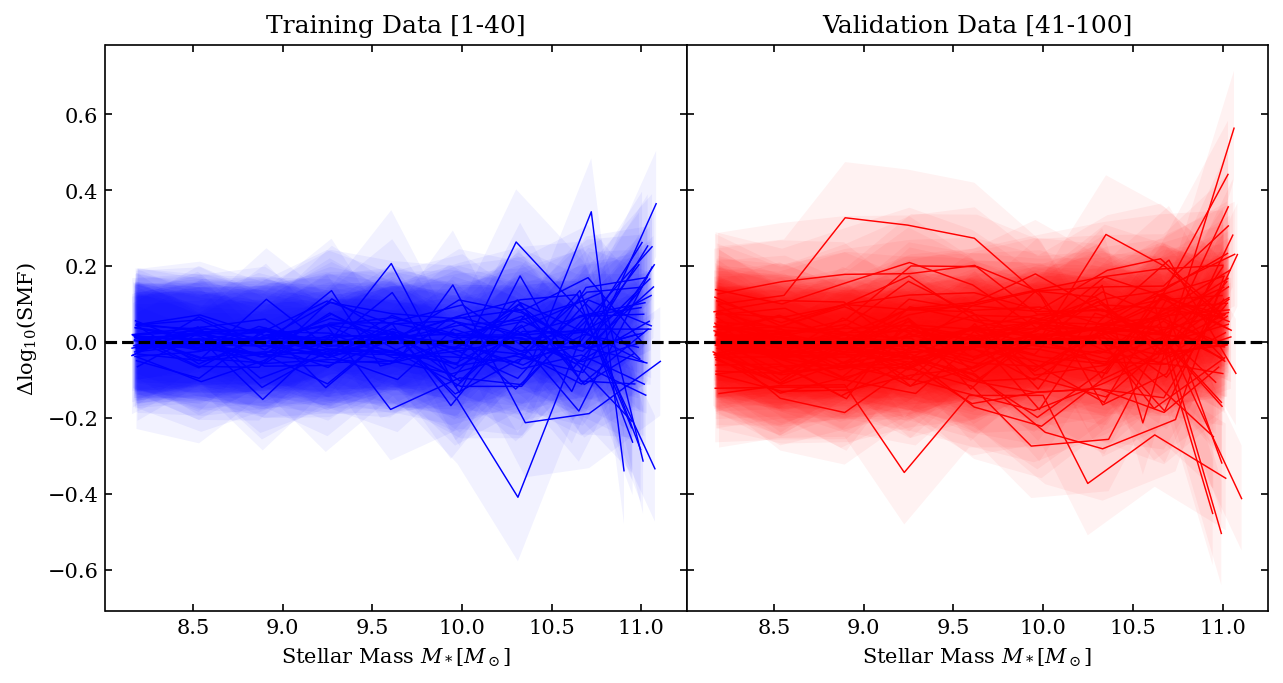

In [455]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=150, sharey=True)
    
    plt.subplots_adjust(wspace=0, hspace=0)

    for i in range(40):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x1 = torch.asarray(pars(train_sel[i], np.log10(smf[train_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred1 = likelihood(model(test_x1))
    
        ax[0].plot(np.log10(smf[train_sel[i]]['mstar'][:-5]),  np.log10(smf[train_sel[i]]['smf'][:-5]) - observed_pred1.mean.numpy(), color='b', lw=0.7)
        ax[0].fill_between(np.log10(smf[train_sel[i]]['mstar'][:-5]), np.log10(smf[train_sel[i]]['smf'][:-5]) - (observed_pred1.mean.numpy()-observed_pred1.stddev.numpy()) , np.log10(smf[train_sel[i]]['smf'][:-5]) - (observed_pred1.mean.numpy()+observed_pred1.stddev.numpy()), alpha=0.05, color='b', edgecolor=None)

    for i in range(60):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x2 = torch.asarray(pars(test_sel[i], np.log10(smf[test_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred2 = likelihood(model(test_x2))
        
        ax[1].plot(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - observed_pred2.mean.numpy(), color='r', lw=0.7)
        ax[1].fill_between(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - (observed_pred2.mean.numpy()-observed_pred2.stddev.numpy()) , np.log10(smf[test_sel[i]]['smf'][:-5]) - (observed_pred2.mean.numpy()+observed_pred1.stddev.numpy()), alpha=0.05, color='r', edgecolor=None)
#        ax[1].fill_between(np.log10(smf[test_sel[i]]['mstar'][:-5]), np.log10(smf[test_sel[i]]['smf'][:-5]) - lower2.numpy(), np.log10(smf[test_sel[i]]['smf'][:-5]) - upper2.numpy(), alpha=0.01, color='r', edgecolor=None)

    # Plot training data as black stars
    ax[0].axhline(0, color='k', ls='--')
    ax[1].axhline(0, color='k', ls='--')

ax[0].set_ylabel('$\Delta \log_{10}(\\mathrm{SMF})$')
ax[0].set_xlabel('Stellar Mass $M_*[M_\odot]$')
ax[1].set_xlabel('Stellar Mass $M_*[M_\odot]$')

ax[0].set_title('Training Data [1-40]')
ax[1].set_title('Validation Data [41-100]')

Text(0.5, 1.0, 'Validation Data [41-100]')

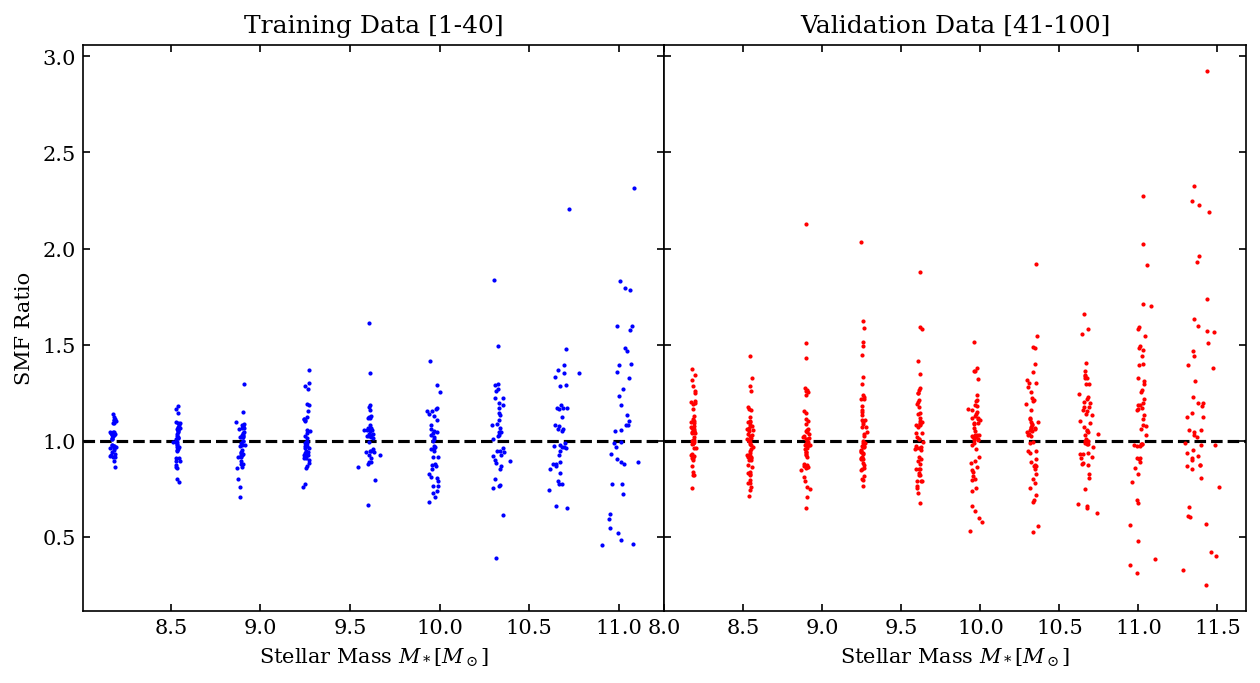

In [426]:
with torch.no_grad():
    # Initialize plot
    f, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=150, sharey=True)
    
    plt.subplots_adjust(wspace=0, hspace=0)

    # Get upper and lower confidence bounds
    lower1, upper1 = observed_pred1.confidence_region()
    lower2, upper2 = observed_pred2.confidence_region()
    # Plot training data as black stars
    ax[0].axhline(1, color='k', ls='--')
    ax[1].axhline(1, color='k', ls='--')

    for i in range(40):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x1 = torch.asarray(pars(train_sel[i], np.log10(smf[train_sel[i]]['mstar'][:-5])), dtype=torch.float)
            observed_pred1 = likelihood(model(test_x1))
            lower1, upper1 = observed_pred1.confidence_region()
    
        ax[0].plot(np.log10(smf[train_sel[i]]['mstar'][:-5]),  smf[train_sel[i]]['smf'][:-5] / 10**observed_pred1.mean.numpy(), color='b', ls='', marker='o', ms=1)

    for i in range(60):
        with torch.no_grad(), gpytorch.settings.fast_pred_var():
            test_x2 = torch.asarray(pars(test_sel[i], np.log10(smf[test_sel[i]]['mstar'][:-4])), dtype=torch.float)
            observed_pred2 = likelihood(model(test_x2))
            lower2, upper2 = observed_pred2.confidence_region()
        
        ax[1].plot(np.log10(smf[test_sel[i]]['mstar'][:-4]), smf[test_sel[i]]['smf'][:-4] / 10**observed_pred2.mean.numpy(), color='r', ls='', marker='o', ms=1)

ax[0].set_ylabel('SMF Ratio')
ax[0].set_xlabel('Stellar Mass $M_*[M_\odot]$')
ax[1].set_xlabel('Stellar Mass $M_*[M_\odot]$')

ax[0].set_title('Training Data [1-40]')
ax[1].set_title('Validation Data [41-100]')